<a href="https://colab.research.google.com/github/sivasankar39/Pokemon_test_detection/blob/main/pokemon_test_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [297]:
import pandas as pd
import numpy as np

Task 1

In [298]:
df = pd.read_csv('/content/G2.csv')
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [299]:
df.columns

Index(['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1',
       'type_2', 'hp', 'attack', 'defense'],
      dtype='object')

In [300]:
df.shape

(1351, 10)

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB


In [302]:
df.select_dtypes(include="number").columns

Index(['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack',
       'defense'],
      dtype='object')

In [303]:
df.select_dtypes(include="object").columns

Index(['name', 'type_1', 'type_2'], dtype='object')

In [304]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [305]:
df.isna().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [306]:
df.isna().mean()*100

,0
id,0.000000
name,0.000000
height_dm,0.000000
weight_hg,0.000000
base_experience,3.626943
type_1,0.000000
type_2,43.375278
hp,0.000000
attack,0.000000
defense,0.000000


In [307]:
df.duplicated().sum()

np.int64(0)

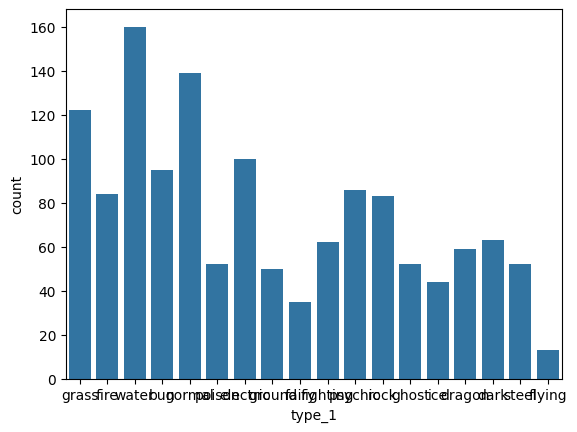

In [308]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="type_1", data=df)
plt.show()

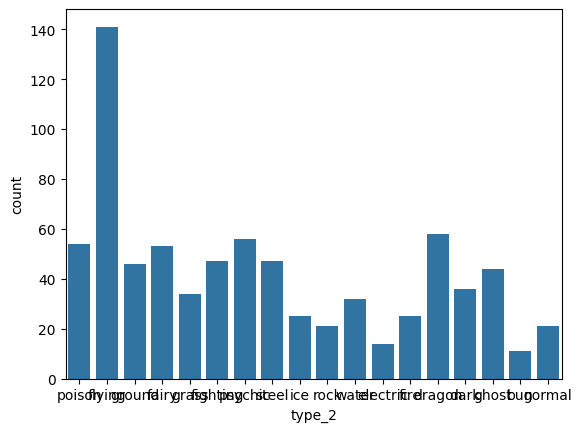

In [309]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="type_2", data=df)
plt.show()

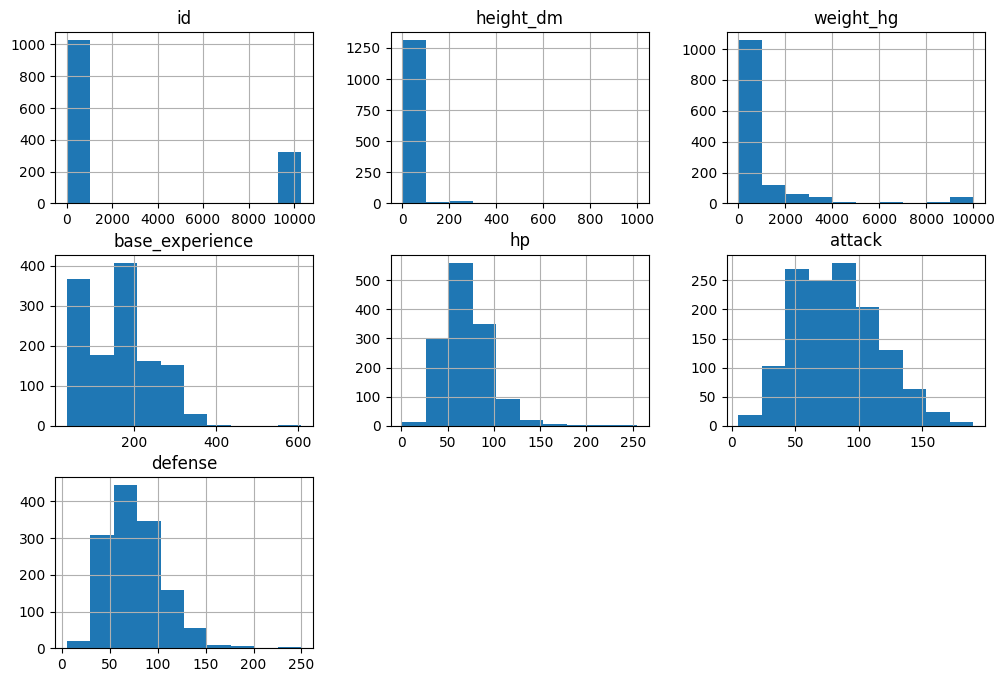

In [310]:
df.hist(figsize=(12, 8))
plt.show()

In [311]:
df.value_counts('type_1')

,count
type_1,
water,160
normal,139
grass,122
electric,100
bug,95
psychic,86
fire,84
rock,83
dark,63


In [312]:
df.value_counts('type_2')

,count
type_2,
flying,141
dragon,58
psychic,56
poison,54
fairy,53
steel,47
fighting,47
ground,46
ghost,44


Water is the most frequently occurring type in type 1

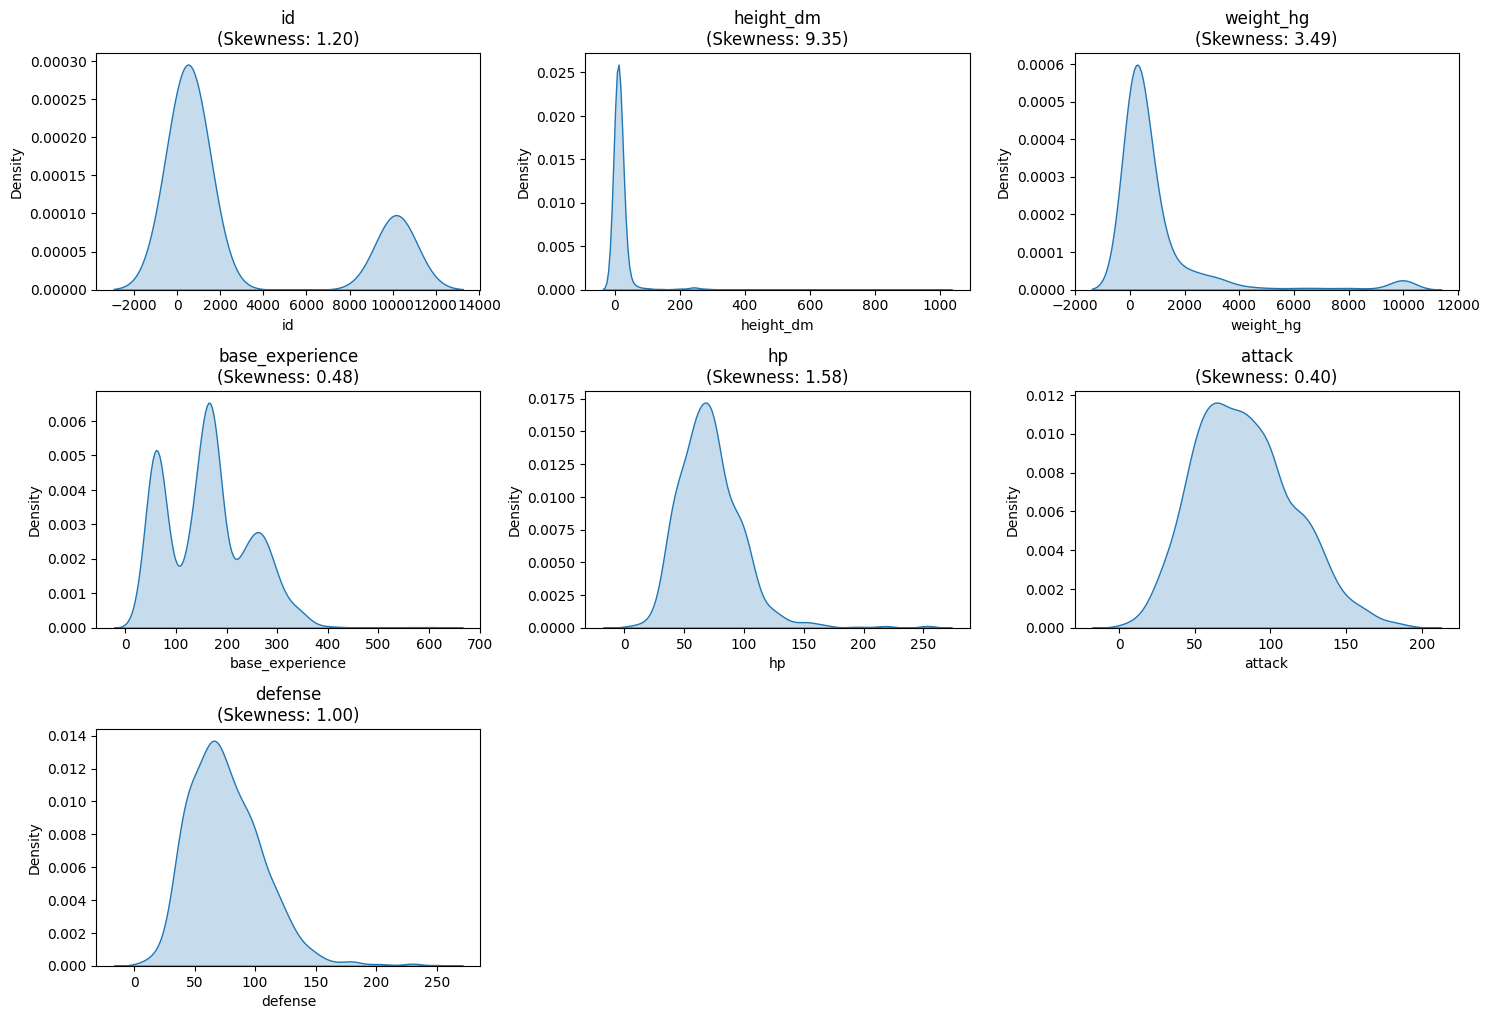

In [313]:
numerical_columns = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(15, 20))

for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(6, 3, idx)
    sns.kdeplot(data=df, x=col, fill=True)

    skewness = df[col].skew()
    plt.title(f'{col}\n(Skewness: {skewness:.2f})')
    plt.tight_layout()

plt.show()

height_dm shows the greatest variation

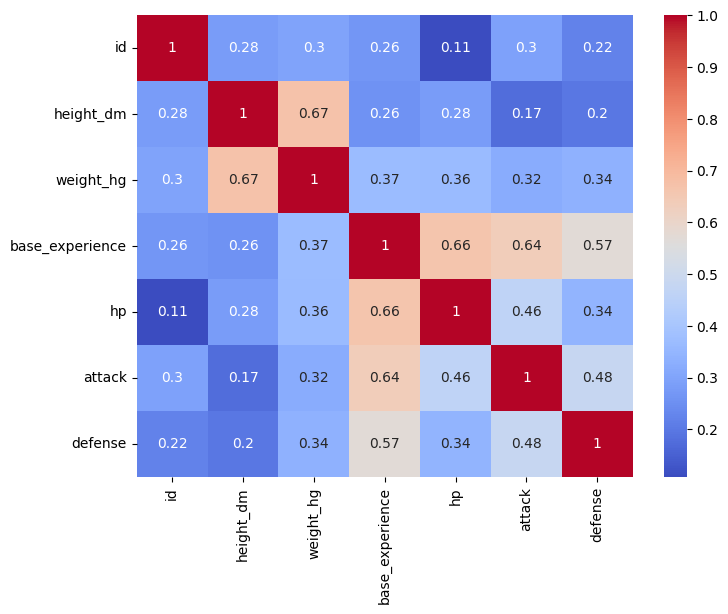

In [314]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

From the dataset

Task 2

In [315]:
df.isna().mean()*100

,0
id,0.000000
name,0.000000
height_dm,0.000000
weight_hg,0.000000
base_experience,3.626943
type_1,0.000000
type_2,43.375278
hp,0.000000
attack,0.000000
defense,0.000000


In [316]:
df = df.drop(columns = 'base_experience')
df.head()

,id,name,height_dm,weight_hg,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,grass,poison,45,49,49
1,2,ivysaur,10,130,grass,poison,60,62,63
2,3,venusaur,20,1000,grass,poison,80,82,83
3,4,charmander,6,85,fire,NaN,39,52,43
4,5,charmeleon,11,190,fire,NaN,58,64,58


In [317]:
df = df.drop(columns = 'id')
df.head()

,name,height_dm,weight_hg,type_1,type_2,hp,attack,defense
0,bulbasaur,7,69,grass,poison,45,49,49
1,ivysaur,10,130,grass,poison,60,62,63
2,venusaur,20,1000,grass,poison,80,82,83
3,charmander,6,85,fire,NaN,39,52,43
4,charmeleon,11,190,fire,NaN,58,64,58


In [318]:
df["type_2"] = df["type_2"].fillna(df["type_2"].mode()[0])
df.head()

,name,height_dm,weight_hg,type_1,type_2,hp,attack,defense
0,bulbasaur,7,69,grass,poison,45,49,49
1,ivysaur,10,130,grass,poison,60,62,63
2,venusaur,20,1000,grass,poison,80,82,83
3,charmander,6,85,fire,flying,39,52,43
4,charmeleon,11,190,fire,flying,58,64,58


In [319]:
df['name'].value_counts()

,count
name,
meowstic-female-mega,1
bulbasaur,1
ivysaur,1
venusaur,1
charmander,1
...,...
butterfree,1
metapod,1
caterpie,1


In [320]:
df = df.drop(columns = 'name')
df.head()

,height_dm,weight_hg,type_1,type_2,hp,attack,defense
0,7,69,grass,poison,45,49,49
1,10,130,grass,poison,60,62,63
2,20,1000,grass,poison,80,82,83
3,6,85,fire,flying,39,52,43
4,11,190,fire,flying,58,64,58


In [321]:
X = df.drop(columns = ["type_1"])
y = df["type_1"]

In [322]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1351, 6)
y shape: (1351,)


In [323]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [324]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1080, 6)
(271, 6)
(1080,)
(271,)


In [325]:
# classification_features = [
#       "height_dm",
#       "weight_hg",
#       "type_2",
#       "hp",
#       "attack",
#       "defense",
# ]
# target_cls = "type_1"

# pokemon_splits = {}
# MIN_SAMPLES = 5

# for id in df["id"].unique():
#     type_df = df[df["id"] == id].copy()

#     if len(type_df) < MIN_SAMPLES or type_df[target_cls].nunique() < 2:
#         continue

#     X = type_df[classification_features]
#     y = type_df[target_cls]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42, stratify=y
#     )

#     pokemon_splits[id] = {
#         "X_train": X_train,
#         "X_test": X_test,
#         "y_train": y_train,
#         "y_test": y_test,
#     }

# for id, splits in pokemon_splits.items():
#     print(f"Pokemon {id}:")
#     print(
#         f"  X_train: {splits['X_train'].shape} | y_train: {splits['y_train'].shape}"
#     )
#     print(
#         f"  X_test : {splits['X_test'].shape}  | y_test : {splits['y_test'].shape}"
#     )

In [326]:
X_train = pd.get_dummies(X_train, columns=["type_2"])
X_test = pd.get_dummies(X_test, columns=["type_2"])

In [327]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [328]:
print(X_train.shape)
print(X_test.shape)

(1080, 23)
(271, 23)


In [329]:
numerical_features = df.select_dtypes(include="number").columns

In [330]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [331]:
X_train[numerical_features].head()

,height_dm,weight_hg,hp,attack,defense
489,-0.314552,-0.505424,1.008639,0.524645,0.788952
205,-0.101252,-0.440430,1.008639,-0.405251,-0.196250
397,-0.154577,-0.384205,0.465278,1.144575,-0.196250
1081,-0.154577,-0.259890,-0.259203,2.074470,-0.524650
133,-0.190127,-0.363056,2.095361,-0.560233,-0.524650


Preprocessing is essential before model training because training should be perfect without any null values or duplicates and values should be in same scale

In tyep_2, missing values are handled using mode as there are 43% of the missing values

Task 3

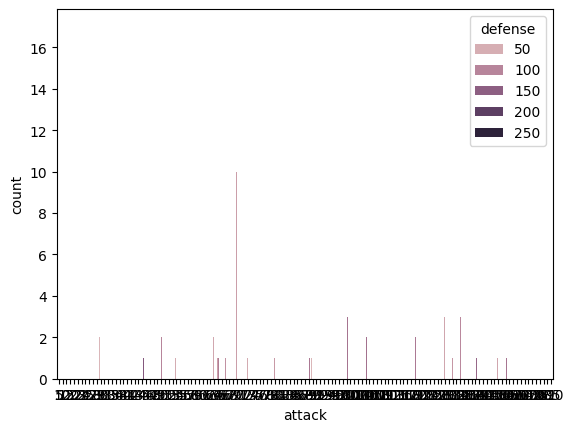

In [332]:
sns.countplot(x="attack", hue="defense", data=df)
plt.show()

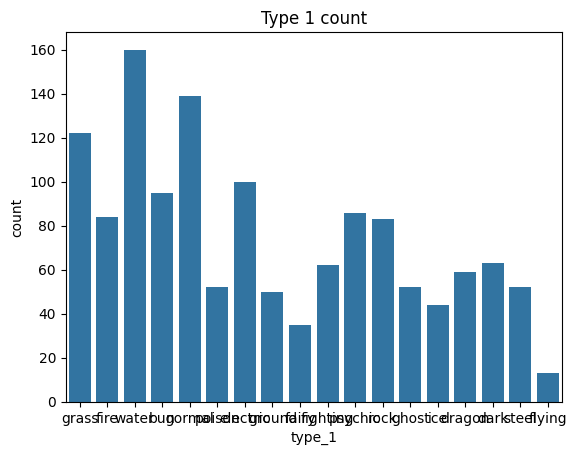

In [333]:
sns.countplot(data=df, x='type_1')
plt.title("Type 1 count")
plt.show()

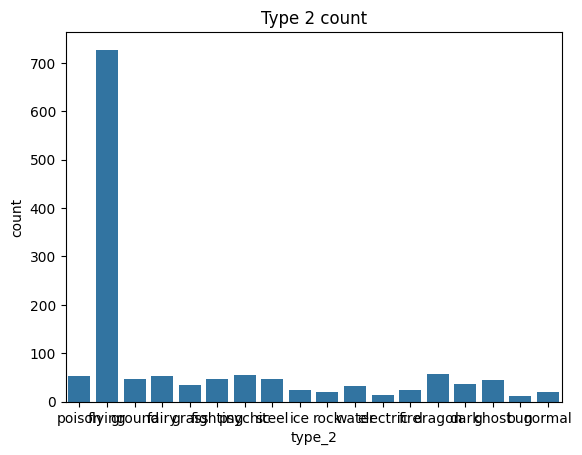

In [334]:
sns.countplot(data=df, x='type_2')
plt.title("Type 2 count")
plt.show()

<Axes: xlabel='height_dm', ylabel='weight_hg'>

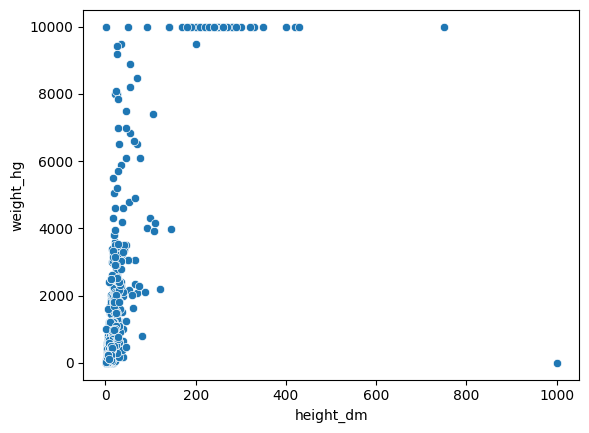

In [335]:
sns.scatterplot(data=df,x='height_dm',y='weight_hg')

Task 4

In [336]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [337]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.1918819188191882


In [338]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [339]:

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.22140221402214022


In [340]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [341]:

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.28044280442804426


In [342]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [343]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.23985239852398524


In [344]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.191882
1,Decision Tree,0.221402
2,Random Forest,0.280443
3,Gradient Boosting,0.239852


In [345]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         bug       0.21      0.32      0.25        19
        dark       0.43      0.23      0.30        13
      dragon       0.40      0.33      0.36        12
    electric       0.39      0.35      0.37        20
       fairy       0.33      0.14      0.20         7
    fighting       0.25      0.17      0.20        12
        fire       0.24      0.24      0.24        17
      flying       0.00      0.00      0.00         3
       ghost       0.08      0.10      0.09        10
       grass       0.39      0.48      0.43        25
      ground       0.40      0.20      0.27        10
         ice       0.00      0.00      0.00         9
      normal       0.33      0.46      0.39        28
      poison       0.12      0.10      0.11        10
     psychic       0.43      0.18      0.25        17
        rock       0.30      0.35      0.32        17
       steel       0.38      0.30      0.33        10
       water       0.16    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [346]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[ 6  0  1  0  0  0  3  0  0  3  0  0  0  0  0  2  0  4]
 [ 1  3  0  0  1  0  1  0  1  1  0  0  4  0  0  0  0  1]
 [ 0  0  4  0  0  0  1  0  0  1  0  0  0  0  0  4  0  2]
 [ 2  1  1  7  0  0  0  0  0  1  0  0  3  2  1  1  0  1]
 [ 0  0  0  1  1  0  0  0  1  2  0  0  1  0  0  0  0  1]
 [ 2  0  1  0  0  2  0  0  0  1  0  0  2  0  0  2  0  2]
 [ 1  0  0  1  0  1  4  0  0  2  0  0  3  0  0  0  1  4]
 [ 0  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 5  0  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0  2]
 [ 4  0  0  3  0  0  0  0  0 12  0  0  1  2  0  1  0  2]
 [ 1  0  0  1  0  2  0  0  0  1  2  0  1  0  0  1  0  1]
 [ 2  0  0  0  0  0  2  0  0  0  0  0  2  0  0  0  0  3]
 [ 1  1  0  1  0  1  3  0  2  1  1  0 13  0  1  0  0  3]
 [ 0  0  0  0  0  0  0  0  2  2  0  0  0  1  0  0  0  5]
 [ 1  1  1  1  1  1  1  0  1  0  2  0  2  0  3  0  0  2]
 [ 1  1  1  0  0  1  0  0  2  1  0  0  0  0  0  6  1  3]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  3  4]
 [ 1  0  1  1  0  0  2  0  2  3

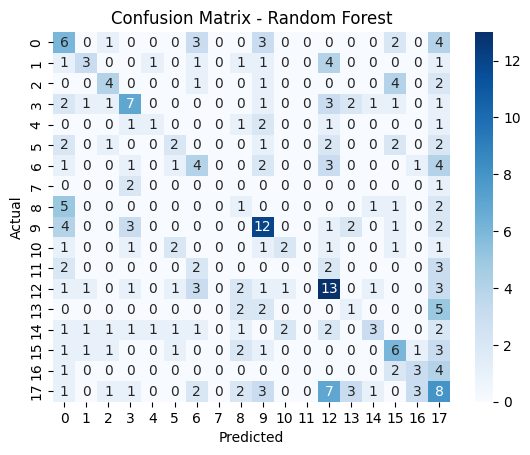

In [347]:


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [348]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print(feature_importance)

weight_hg          0.198703
attack             0.192298
hp                 0.185162
defense            0.181090
height_dm          0.138960
type_2_flying      0.013814
type_2_psychic     0.011081
type_2_grass       0.008527
type_2_dark        0.008503
type_2_ghost       0.008331
type_2_fighting    0.007327
type_2_ground      0.006286
type_2_dragon      0.006261
type_2_steel       0.006247
type_2_normal      0.004453
type_2_water       0.004406
type_2_fairy       0.004331
type_2_rock        0.004293
type_2_poison      0.003890
type_2_electric    0.002749
type_2_fire        0.001786
type_2_ice         0.001499
type_2_bug         0.000000
dtype: float64


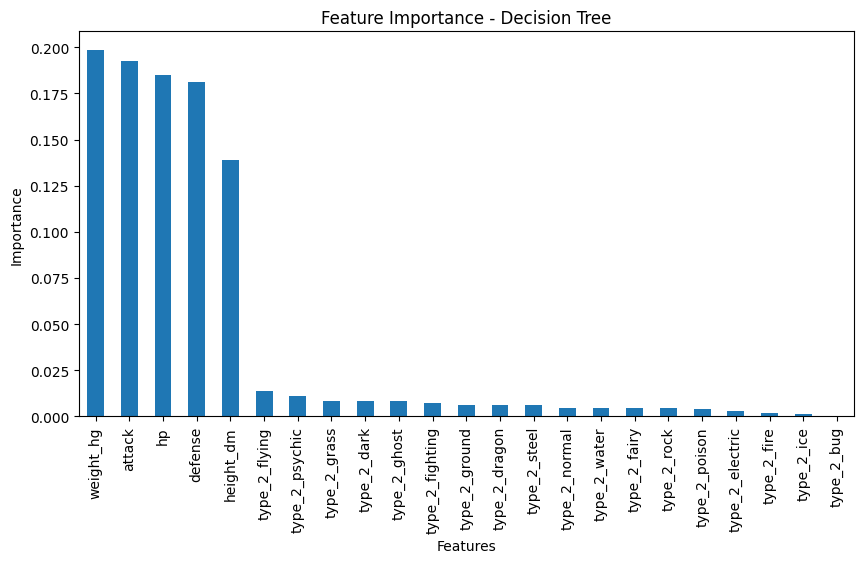

In [349]:
feature_importance.plot(kind="bar", figsize=(10, 5))

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [353]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [354]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation Score:")
print(rf_grid.best_score_)

print("\nBest Model:")
print(rf_grid.best_estimator_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Score:
0.2740740740740741

Best Model:
RandomForestClassifier(max_depth=10, random_state=42)


In [355]:

tuned_rf = rf_grid.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_rf_pred)

print("Tuned Rnadom Forest Test Accuracy:", tuned_accuracy)

Tuned Rnadom Forest Test Accuracy: 0.26199261992619927


In [356]:

print("Classification Report - Tuned Random Forest")
print(classification_report(y_test, tuned_rf_pred))

Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

         bug       0.29      0.32      0.30        19
        dark       0.50      0.08      0.13        13
      dragon       0.27      0.25      0.26        12
    electric       0.44      0.35      0.39        20
       fairy       1.00      0.14      0.25         7
    fighting       0.00      0.00      0.00        12
        fire       0.22      0.12      0.15        17
      flying       0.00      0.00      0.00         3
       ghost       0.25      0.20      0.22        10
       grass       0.45      0.40      0.43        25
      ground       0.00      0.00      0.00        10
         ice       0.00      0.00      0.00         9
      normal       0.30      0.57      0.39        28
      poison       0.00      0.00      0.00        10
     psychic       0.33      0.24      0.28        17
        rock       0.18      0.24      0.21        17
       steel       0.40      0.40    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [357]:

tuned_cm = confusion_matrix(y_test, tuned_rf_pred)

print(tuned_cm)

[[ 6  0  1  0  0  1  2  0  0  2  0  0  1  0  0  1  0  5]
 [ 1  1  0  0  0  0  0  0  1  1  0  0  3  0  1  1  0  4]
 [ 0  0  3  0  0  0  0  0  0  1  0  0  0  0  0  4  0  4]
 [ 2  0  0  7  0  0  0  0  0  1  0  0  6  0  1  1  0  2]
 [ 0  0  0  1  1  0  0  0  1  1  0  0  2  0  0  0  0  1]
 [ 0  0  1  0  0  0  0  0  0  1  0  0  3  0  0  2  1  4]
 [ 0  0  0  0  0  0  2  0  0  1  0  0  6  0  1  1  1  5]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  2]
 [ 4  0  0  0  0  0  0  0  2  1  0  0  0  0  1  1  0  1]
 [ 3  0  0  2  0  0  0  0  0 10  0  0  0  0  1  3  0  6]
 [ 0  0  1  2  0  0  0  0  0  1  0  0  1  0  0  1  0  4]
 [ 1  0  0  0  0  0  2  0  0  0  0  0  1  0  0  0  0  5]
 [ 0  0  0  2  0  0  1  0  1  1  2  0 16  0  0  0  0  5]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  2  0  0  1  0  6]
 [ 1  0  2  0  0  0  1  0  1  1  0  0  3  0  4  1  0  3]
 [ 1  1  1  0  0  0  0  0  1  0  0  0  1  1  0  4  1  6]
 [ 1  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  4  3]
 [ 1  0  2  1  0  0  1  0  0  0

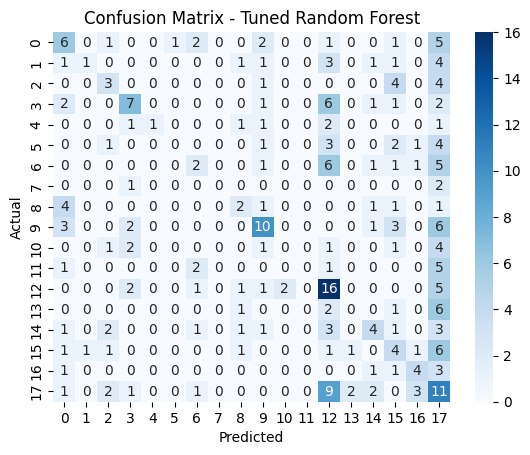

In [358]:


sns.heatmap(tuned_cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")

plt.show()

Random forest is chosen as the best model since it have the highest accuracy, also compared the f1 score

In [360]:

import pickle
pickle.dump(rf_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("std_scalar.pkl", "wb"))